In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [11]:
# Data
data = {
      'Model': ['Native', 'ProteinMPNN', 'ESM-IF', 'PiFold', 'RedNet', 'RedNet-CD'],
      'SR (Diff <-10)': [25.93, 31.48, 35.19, 27.78, 22.22, 33.33],
      'SR (Diff <-5)': [33.33, 44.44, 42.59, 40.74, 27.78, 51.85],
      'SR (Diff <0)': [50.00, 53.70, 53.70, 55.56, 33.33, 64.81],
}


df = pd.DataFrame(data)


In [20]:
def plot_sel_bar(df):
  df = pd.DataFrame(data).set_index('Model')
  thresholds = ['SR (Diff <-10)', 'SR (Diff <-5)', 'SR (Diff <0)']

  BREAK_LO, BREAK_HI = 0, 25
  COMPRESSED_SIZE = 4

  def transform(y):
      y = np.asarray(y, dtype=float)
      return np.where(
          y <= BREAK_HI,
          (y - BREAK_LO) / (BREAK_HI - BREAK_LO) * COMPRESSED_SIZE,
          COMPRESSED_SIZE + (y - BREAK_HI)
      )

  fig, ax = plt.subplots(figsize=(6, 4))

  for model in ['Native', 'ProteinMPNN', 'ESM-IF', 'PiFold']:
      ax.plot(thresholds, transform(df.loc[model]), marker='o', linewidth=1.5,
              alpha=0.4, linestyle='--', label=model, markersize=5)

  ax.plot(thresholds, transform(df.loc['RedNet']), marker='s', linewidth=3,
          color='#e74c3c', label='RedNet', markersize=6)
  ax.plot(thresholds, transform(df.loc['RedNet-CD']), marker='D', linewidth=3,
          color='#c0392b', label='RedNet-CD', markersize=6)

  # Y-ticks: 0% at bottom, 25% at top of compressed zone, then normal
  real_ticks = [0, 25, 30, 35, 40, 45, 50, 55, 60, 65]
  ax.set_yticks(transform(real_ticks))
  ax.set_yticklabels([f'{t:.0f}%' for t in real_ticks])

  # // break — midway between 0% and 25% ticks
  break_mid = COMPRESSED_SIZE / 2
  d = 0.5
  sep = 0.25

  kwargs = dict(transform=ax.get_yaxis_transform(), clip_on=False)
  ax.fill_between([-0.04, 0.04], break_mid - d * 2, break_mid + d * 2,
                  color='white', zorder=5, **kwargs)

  for offset in [-sep, sep]:
      ax.plot([-0.015, 0.015],
              [break_mid - d + offset, break_mid + d + offset],
              color='k', linewidth=1, zorder=6, **kwargs)

  ax.set_xlabel('Threshold')
  ax.set_ylabel('Success Rate (%)')
  ax.set_title('Success Rate by Model and Threshold')
  ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
  ax.margins(x=0.05)
  plt.tight_layout()
  plt.savefig('success_rate_lineplot.png', dpi=150, bbox_inches='tight')
  plt.show()

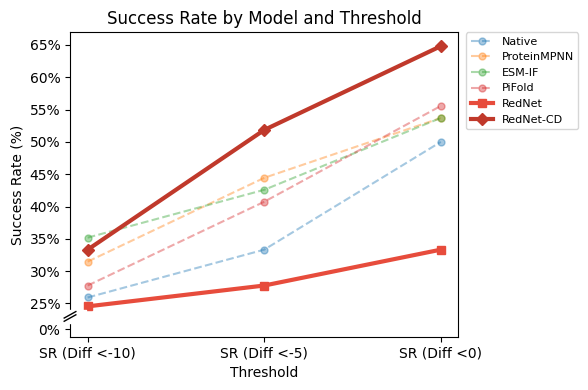

In [21]:
plot_sel_bar(df)

In [10]:
# Data
models = ['ESM-IF', 'PiFold', 'ProteinMPNN', 'RedNet (σ=0)', 'RedNet (σ=0.02)']
metrics = ['ll', 'global', 'mt', 'ref', 'cd_ll', 'cd_ll_ref']

spearman = [
      [0.16, 0.24, 0.20, 0.20, 0.15, 0.15],
      [0.17, -0.17, -0.03, -0.12, 0.15, 0.00],
      [0.17, 0.17, 0.23, 0.26, 0.10, 0.24],
      [0.18, 0.23, 0.21, 0.22, 0.23, 0.26],
      [0.21, 0.26, 0.22, 0.24, 0.26, 0.28],
]

df = pd.DataFrame(spearman, index=models, columns=metrics)

In [13]:

def plot_heatmap(df):
  # Heatmap
  plt.figure(figsize=(10, 5))
  sns.heatmap(df, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
  plt.title('Spearman ρ Correlation')
  plt.tight_layout()
  # plt.savefig('spearman_heatmap.png', dpi=150)
  plt.show()

def plot_barplot(df):
  # Grouped bar plot
  df_melted = df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Spearman ρ')
  df_melted.rename(columns={'index': 'Model'}, inplace=True)

  plt.figure(figsize=(12, 5))
  sns.barplot(data=df_melted, x='Metric', y='Spearman ρ', hue='Model', palette='Set2')
  plt.title('Spearman ρ by Model and Metric')
  plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
  plt.tight_layout()
  # plt.savefig('spearman_barplot.png', dpi=150)
  plt.show()


def plot_lines(df):
  fig, ax = plt.subplots(figsize=(6, 4))

  for model in ['ESM-IF', 'PiFold', 'ProteinMPNN']:
      ax.plot(metrics, df.loc[model], marker='o', linewidth=1.5,
              alpha=0.4, linestyle='--', label=model, markersize=5)

  ax.plot(metrics, df.loc['RedNet (σ=0)'], marker='s', linewidth=3,
          color='#e74c3c', label='RedNet (σ=0)', markersize=6)
  ax.plot(metrics, df.loc['RedNet (σ=0.02)'], marker='D', linewidth=3,
          color='#c0392b', label='RedNet (σ=0.02)', markersize=6)

  ax.set_ylim(0.10, 0.30)
  ax.set_xlabel('Metric')
  ax.set_ylabel('Spearman ρ')
  ax.set_title('Spearman ρ Correlation by Model')
  ax.legend(fontsize=8, loc='lower left')
  ax.margins(x=0.05)
  plt.tight_layout()
  plt.savefig('spearman_lineplot.png', dpi=150, bbox_inches='tight')
  plt.show()

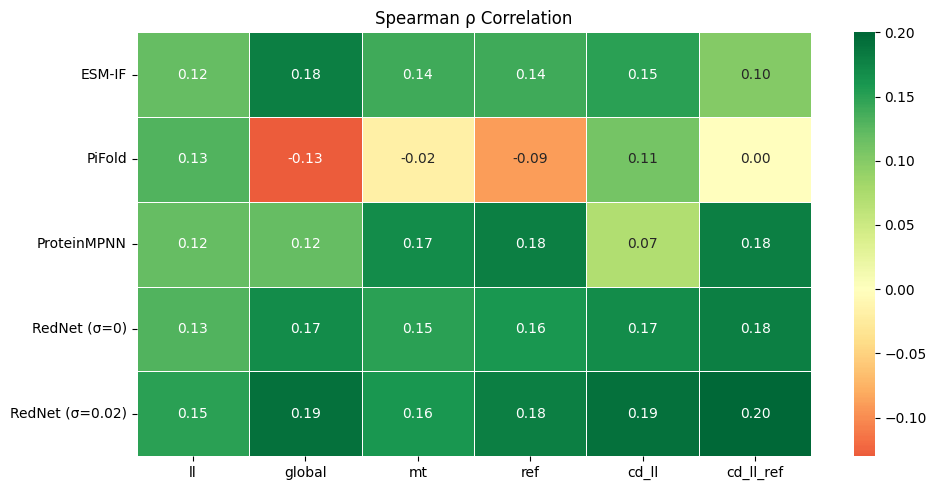

In [4]:
plot_heatmap(df)

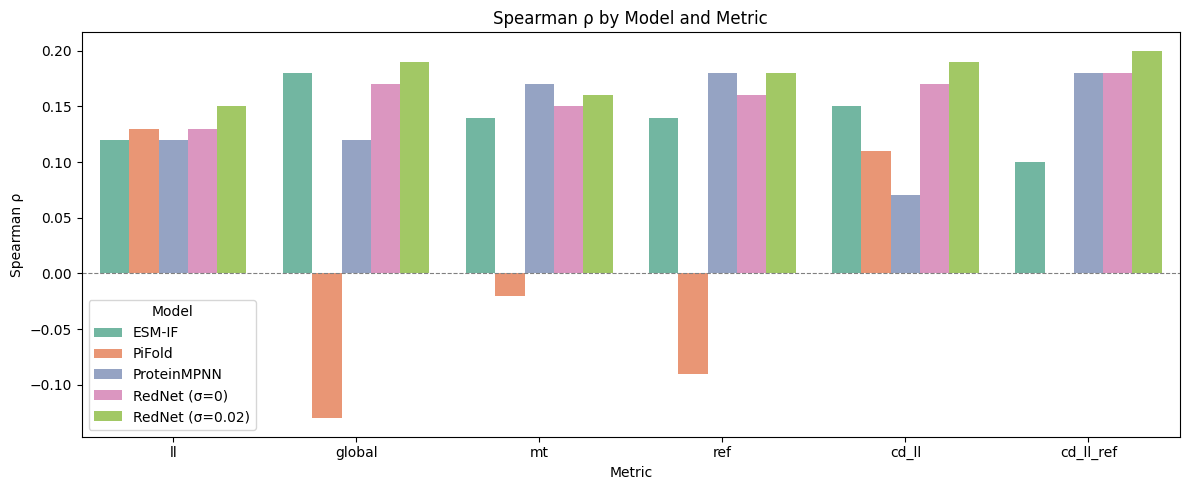

In [5]:
plot_barplot(df)

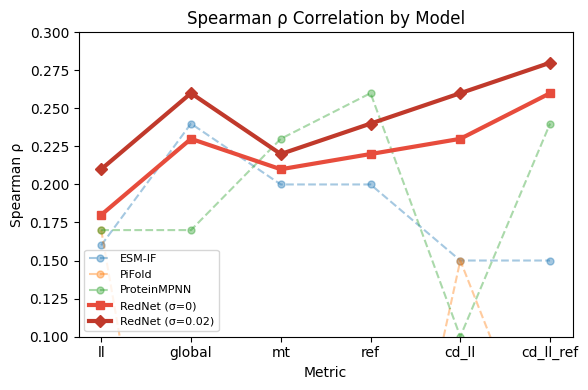

In [14]:
plot_lines(df)

In [27]:
def plot_compressed_lines(df):
  BREAK_LO, BREAK_HI = -0.2, 0.15
  COMPRESSED_SIZE = 0.03
  def transform(y):
      y = np.asarray(y, dtype=float)
      return np.where(
          y <= BREAK_HI,
          (y - BREAK_LO) / (BREAK_HI - BREAK_LO) * COMPRESSED_SIZE,
          COMPRESSED_SIZE + (y - BREAK_HI)
      )

  fig, ax = plt.subplots(figsize=(6, 4))

  for model in ['ESM-IF', 'PiFold', 'ProteinMPNN']:
      ax.plot(metrics, transform(df.loc[model]), marker='o', linewidth=1.5,
              alpha=0.4, linestyle='--', label=model, markersize=5)

  ax.plot(metrics, transform(df.loc['RedNet (σ=0)']), marker='s', linewidth=3,
          color='#e74c3c', label='RedNet (σ=0)', markersize=6)
  ax.plot(metrics, transform(df.loc['RedNet (σ=0.02)']), marker='D', linewidth=3,
          color='#c0392b', label='RedNet (σ=0.02)', markersize=6)

  # Y-ticks: only -0.2, 0.15, and above — no ticks inside compressed zone
  real_ticks = [-0.2, 0.15, 0.20, 0.25, 0.30]
  ax.set_yticks(transform(real_ticks))
  ax.set_yticklabels([f'{t:.2f}' for t in real_ticks])

  # // break — placed midway in compressed zone, between the -0.2 and 0.15 ticks
  break_mid = COMPRESSED_SIZE / 2  # middle of compressed region
  d = 0.004
  sep = 0.002

  kwargs = dict(transform=ax.get_yaxis_transform(), clip_on=False)
  ax.fill_between([-0.04, 0.04], break_mid - d * 2, break_mid + d * 2,
                  color='white', zorder=5, **kwargs)

  for offset in [-sep, sep]:
      ax.plot([-0.015, 0.015],
              [break_mid - d + offset, break_mid + d + offset],
              color='k', linewidth=1, zorder=6, **kwargs)

  ax.set_xlabel('Metric')
  ax.set_ylabel('Spearman ρ')
  ax.set_title('Spearman ρ Correlation by Model')
  ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
  ax.margins(x=0.05)
  plt.tight_layout()
  plt.savefig('spearman_lineplot.png', dpi=150, bbox_inches='tight')
  plt.show()

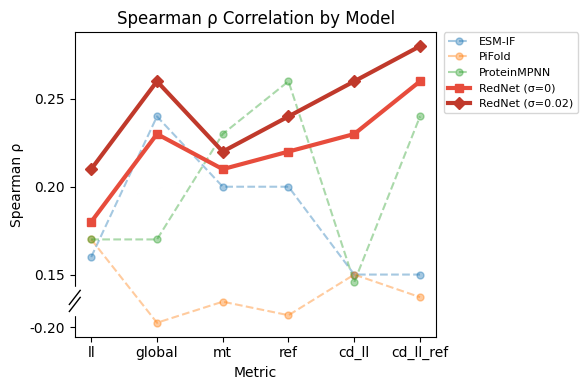

In [28]:
plot_compressed_lines(df)